In [ ]:
from pathlib import Path
import pickle

import shap
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

c:\Users\ishar\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
df = pd.read_excel("../data/Telco_customer_churn.xlsx")

df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
df.dropna(inplace=True)

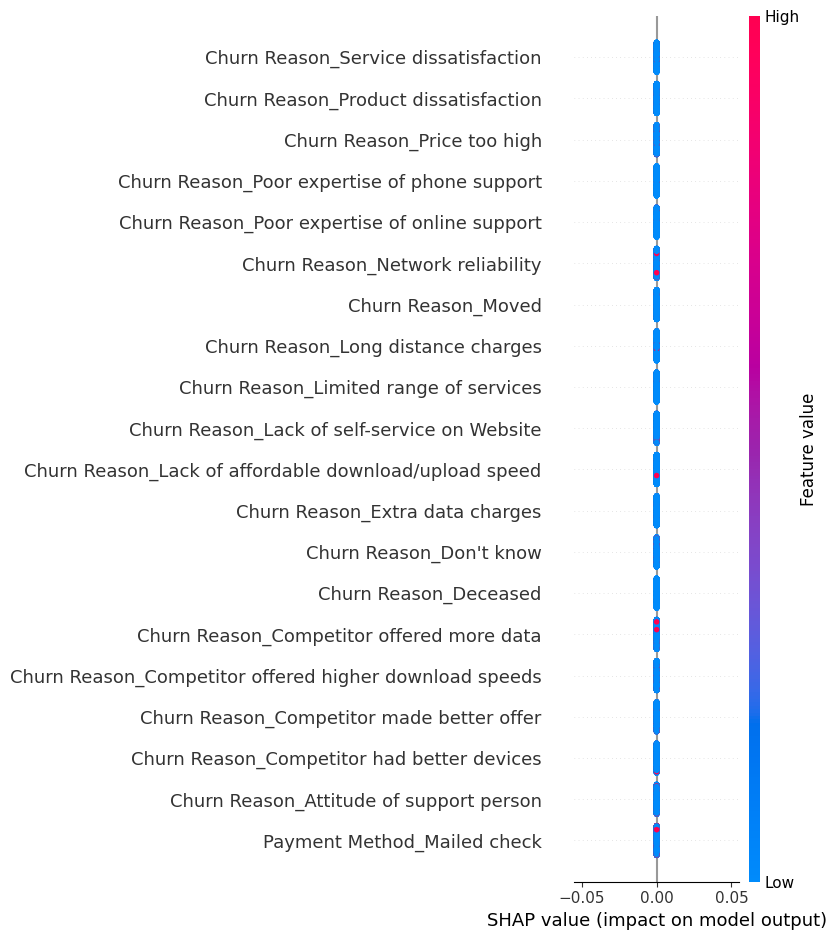

In [ ]:
import numpy as np

base_dir = Path.cwd()
if not (base_dir / "app").exists():
    base_dir = base_dir.parent

model_path = base_dir / "app" / "artifacts" / "churn_model.pkl"
df = pd.read_excel(base_dir / "data" / "Telco_customer_churn.xlsx")
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
df["CLTV"] = pd.to_numeric(df["CLTV"], errors="coerce")
df.dropna(subset=["Total Charges", "CLTV", "Churn Value"], inplace=True)

feature_cols = [
    "Gender",
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Tenure Months",
    "Phone Service",
    "Multiple Lines",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Contract",
    "Paperless Billing",
    "Payment Method",
    "Monthly Charges",
    "Total Charges",
    "CLTV",
]

X = df[feature_cols].copy()
y = df["Churn Value"].astype(int).copy()

with model_path.open("rb") as f:
    model = pickle.load(f)

preprocessor = model.named_steps["preprocessing"]
classifier = model.named_steps["classifier"]
X_transformed = preprocessor.transform(X)
feature_names = preprocessor.get_feature_names_out()

explainer = shap.TreeExplainer(classifier)
shap_values = explainer.shap_values(X_transformed)

# Handle SHAP output shape differences across versions and class counts.
if isinstance(shap_values, list):
    class_idx = 1 if len(shap_values) > 1 else 0
    sv_for_plot = shap_values[class_idx]
else:
    if getattr(shap_values, "ndim", 0) == 3:
        class_idx = 1 if shap_values.shape[2] > 1 else 0
        sv_for_plot = shap_values[:, :, class_idx]
    else:
        class_idx = 0
        sv_for_plot = shap_values

shap.summary_plot(sv_for_plot, X_transformed, feature_names=feature_names)

expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    ev = expected_value[class_idx] if np.ndim(expected_value) > 0 else expected_value
else:
    ev = expected_value

shap.plots._waterfall.waterfall_legacy(
    ev,
    sv_for_plot[0],
    feature_names=feature_names,
)